# This notebook generates figures S1B and C

In [2]:
# Read packages
from pyboolnet import state_transition_graphs, file_exchange
from pyboolnet.attractors import compute_attractors_tarjan
from graphviz import Digraph

In [3]:
# Functions to manipulate colors
def clarear_cor(hex_color, percent):
    """Lightens a HEX color by the specified percentage."""
    rgb = tuple(int(hex_color.lstrip('#')[i:i+2], 16) for i in (0, 2, 4))
    return '#%02x%02x%02x' % tuple(rgb)

def escurecer_cor(hex_color, percent):
    """Darkens a HEX color by the specified percentage."""
    rgb = tuple(int(hex_color.lstrip('#')[i:i+2], 16) for i in (0, 2, 4))
    rgb = [int(c * (100 - percent) / 100) for c in rgb]
    return '#%02x%02x%02x' % tuple(rgb)

In [4]:
# Personalization options
mostrar_labels_transicoes = False
mostrar_labels_estaveis_ciclicos = True
estilo_grafo = "dot"

In [12]:
# Read the model file
bnet = 'working_data/logical_model_CSC_ewing_sarcoma.bnet'
primes = file_exchange.bnet2primes(bnet)

In [13]:
# Color personalization
cor_borda_inicial = "#4e79a7"
cor_borda_ciclico = "#FFA500"


# Colors based on the Stem_b1 e Stem_b2 nodes
gradiente_cores = {
    "00": "#55308d",  # Both inactive
    "01": "#434343",  # Stem_b2 active
    "10": "#ffb66c",  # Stem_b1 active
    "11": "#ea7500",  # Both active
}

Stable states: ['0010000001', '0011101000', '1101111110', '1111101000']
Cyclic states: []


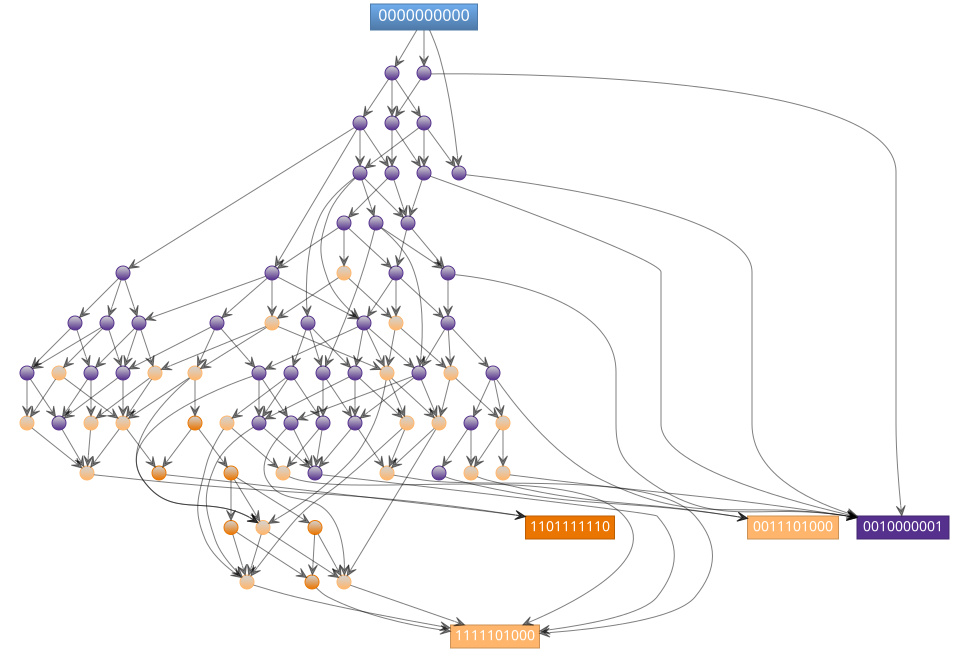

In [14]:
# Generate state transition graph (STG)
initial_state = "0000000000"
stg = state_transition_graphs.primes2stg(primes, "asynchronous", initial_states={"EWS_FLI1": 0, "miR_145": 0, "Let_7": 0, "STAT3": 0, "LIN28": 0,
    "c_Myc": 0, "OCT4": 0, "SOX2": 0, "Stem_b1": 0, "Stem_b2": 0
})

# Identifying attractors
steady, cyclic = compute_attractors_tarjan(stg)


# State colors
cores_especificas_estaveis = {
    "0010000001": "#55308d", 
    "0111101000": "#ffb66c",  
    '1101111110': '#ea7500',
    '1111101000': '#ffb66c',
    '0011101000': '#ffb66c'
}

# Personalized labels.
# Simulation order ['EWS_FLI1', 'LIN28', 'Let_7', 'OCT4', 'SOX2', 'STAT3', 'Stem_b1', 'Stem_b2', 'c_Myc', 'miR_145']
rotulos_personalizados = {
    "0000000000": "0000000000",
    "0010000001": "0010000001",
    "0011101000": "0011101000",
    '1101111110': '1101111110', 
    '1111101000': '1111101000'
}



# Digraph object
graph = Digraph(engine=estilo_grafo)
graph.attr(overlap="scale", style="filled", fontsize="10")

# Add nodes with custom font colors and sizes
for state in stg.nodes():
    stem_b1_state = state[list(primes.keys()).index("Stem_b1")]
    stem_b2_state = state[list(primes.keys()).index("Stem_b2")]
    key = f"{stem_b1_state}{stem_b2_state}"
    base_color = gradiente_cores.get(key, "gray")

    # Standart set
    fillcolor = f"{base_color}:lightgray"
    fontcolor = "black"
    shape = "circle"
    label = rotulos_personalizados.get(state, "")
    cor_borda = base_color
    
    # Font size personalization
    if state == initial_state:
        font_settings = {'fontsize': '16', 'fontname': 'Arial bold'}  
    elif state in steady:
        font_settings = {'fontsize': '14', 'fontname': 'Arial bold'}  
    elif any(state in cycle for cycle in cyclic):
        font_settings = {'fontsize': '12', 'fontname': 'Arial bold'}  
    else:
        font_settings = {'fontsize': '10'}  

    # State personalization
    if state in steady:
        cor_estavel = cores_especificas_estaveis.get(state, "#59a14f")
        fillcolor = f"{cor_estavel}:{clarear_cor(cor_estavel, 30)}"
        fontcolor = "white"
        shape = "rect"
        cor_borda = escurecer_cor(cor_estavel, 20)
    elif any(state in cycle for cycle in cyclic):
        fillcolor = "orange:red"
        shape = "rect"
        cor_borda = cor_borda_ciclico
    elif state == initial_state:
        fillcolor = "#4e79a7:#70adee"
        fontcolor = "white"
        shape = "rect"
        cor_borda = cor_borda_inicial

     # Create node in graph with font settings
    graph.node(state, label=label, shape=shape, style="filled",
               fillcolor=fillcolor, fontcolor=fontcolor,
               width="0.2", height="0.2", gradientangle="90",
               color=cor_borda, **font_settings)

# Condensate transient states
with graph.subgraph(name="cluster_transientes") as subgraph:
    subgraph.attr(style="filled", color="white", label="", fontcolor="black")
    for state in stg.nodes():
        if state not in steady and not any(state in cycle for cycle in cyclic) and state != initial_state:
            subgraph.node(state)

# Add egdes
for source, target in stg.edges():
    if source == target:
        continue

    label = ""
    if mostrar_labels_estaveis_ciclicos and (target in steady or any(target in cycle for cycle in cyclic)):
        for idx, gene in enumerate(primes.keys()):
            if gene != "input":
                source_val = int(source[idx])
                target_val = int(target[idx])

                if source_val != target_val:
                    transition_direction = "↑" if target_val > source_val else "↓"
                    label = f"{gene} {transition_direction}"
                    break
    elif mostrar_labels_transicoes:
        for idx, gene in enumerate(primes.keys()):
            if gene != "input":
                source_val = int(source[idx])
                target_val = int(target[idx])

                if source_val != target_val:
                    transition_direction = "↑" if target_val > source_val else "↓"
                    label = f"{gene} {transition_direction}"
                    break

    graph.edge(source, target, label='', color="#00000080", style="solid", 
               arrowhead="vee", constraint="true", decorate="true",
               labeldistance="-10.5", labelangle="-30")

# Render and salve graph
graph.render("Results/Figure-1/Figure-1B.svg", format="svg", cleanup=True)

print('Stable states:', steady)
print('Cyclic states:', cyclic)

graph

In [16]:
# Generate state transition graph (STG)
initial_state = "1000000000"
stg = state_transition_graphs.primes2stg(primes, "asynchronous", initial_states={"EWS_FLI1": 1, "miR_145": 0, "Let_7": 0, "STAT3": 0, "LIN28": 0,
    "c_Myc": 0, "OCT4": 0, "SOX2": 0, "Stem_b1": 0, "Stem_b2": 0
})

# Identifying attractors
steady, cyclic = compute_attractors_tarjan(stg)


# State colors
cores_especificas_estaveis = {
    "0010000001": "#55308d",
    "0111101000": "#ffb66c",  
    '1111101000': "#ffb66c",
    "1101111110": "#ea7500",
    '1011101000': '#ffb66c'
}

# Personalized labels.
# Simulation order ['EWS_FLI1', 'LIN28', 'Let_7', 'OCT4', 'SOX2', 'STAT3', 'Stem_b1', 'Stem_b2', 'c_Myc', 'miR_145']
rotulos_personalizados = {
    "1000000000": "1000000000",
    "1101111110": "1101111110", 
    "1111101000": "1111101000", 
    '1011101000': '1011101000'
}

# Digraph object
graph = Digraph(engine=estilo_grafo)
graph.attr(overlap="scale", style="filled", fontsize="10")

# Add nodes with custom font colors and sizes
# Add nodes with custom font colors and sizes
for state in stg.nodes():
    stem_b1_state = state[list(primes.keys()).index("Stem_b1")]
    stem_b2_state = state[list(primes.keys()).index("Stem_b2")]
    key = f"{stem_b1_state}{stem_b2_state}"
    base_color = gradiente_cores.get(key, "gray")

    # Standart set
    fillcolor = f"{base_color}:lightgray"
    fontcolor = "black"
    shape = "circle"
    label = rotulos_personalizados.get(state, "")
    cor_borda = base_color
    
    # Font size personalization
    if state == initial_state:
        font_settings = {'fontsize': '16', 'fontname': 'Arial bold'}  
    elif state in steady:
        font_settings = {'fontsize': '14', 'fontname': 'Arial bold'}  
    elif any(state in cycle for cycle in cyclic):
        font_settings = {'fontsize': '12', 'fontname': 'Arial bold'}  
    else:
        font_settings = {'fontsize': '10'}  

    # State personalization
    if state in steady:
        cor_estavel = cores_especificas_estaveis.get(state, "#59a14f")
        fillcolor = f"{cor_estavel}:{clarear_cor(cor_estavel, 30)}"
        fontcolor = "white"
        shape = "rect"
        cor_borda = escurecer_cor(cor_estavel, 20)
    elif any(state in cycle for cycle in cyclic):
        fillcolor = "orange:red"
        shape = "rect"
        cor_borda = cor_borda_ciclico
    elif state == initial_state:
        fillcolor = "#4e79a7:#70adee"
        fontcolor = "white"
        shape = "rect"
        cor_borda = cor_borda_inicial

     # Create node in graph with font settings
    graph.node(state, label=label, shape=shape, style="filled",
               fillcolor=fillcolor, fontcolor=fontcolor,
               width="0.2", height="0.2", gradientangle="90",
               color=cor_borda, **font_settings)

# Condensate transient states
with graph.subgraph(name="cluster_transientes") as subgraph:
    subgraph.attr(style="filled", color="white", label="", fontcolor="black")
    for state in stg.nodes():
        if state not in steady and not any(state in cycle for cycle in cyclic) and state != initial_state:
            subgraph.node(state)

# Add egdes
for source, target in stg.edges():
    if source == target:
        continue

    label = ""
    if mostrar_labels_estaveis_ciclicos and (target in steady or any(target in cycle for cycle in cyclic)):
        for idx, gene in enumerate(primes.keys()):
            if gene != "input":
                source_val = int(source[idx])
                target_val = int(target[idx])

                if source_val != target_val:
                    transition_direction = "↑" if target_val > source_val else "↓"
                    label = f"{gene} {transition_direction}"
                    break
    elif mostrar_labels_transicoes:
        for idx, gene in enumerate(primes.keys()):
            if gene != "input":
                source_val = int(source[idx])
                target_val = int(target[idx])

                if source_val != target_val:
                    transition_direction = "↑" if target_val > source_val else "↓"
                    label = f"{gene} {transition_direction}"
                    break

    graph.edge(source, target, label='', color="#00000080", style="solid", 
               arrowhead="vee", constraint="true", decorate="true",
               labeldistance="-10.5", labelangle="-30")

# Render and save graph
graph.render("Results/Figure-1/Figure-1C.svg", format="svg", cleanup=True)

print('Stable states:', steady)
print('Cyclic states:', cyclic)

#graph

Stable states: ['1011101000', '1101111110', '1111101000']
Cyclic states: []
